<h2>Predviđanje nivoa zavisnosti od mobilnih telefona kod tinejdžera - 2. Modeli</h2>
<h3>Uvod</h3>

U drugom delu rada, bavićemo se treniranjem i evauluacijom performansi različitih modela poput: Linearne regresije, XGBoost, KNN, i MLP NN. 

<h3>Pretprocesiranje</h3>

Za početak nedostajuće vrednosti i duplikati nisu pronadjeni. Atribut School_Grade čije su vrednosti bile redni brojevi na engleskom, su prebačeni u brojeve ('Seventh' -> 7). Kolona Location je izbačena jer nema nikakav uticaj na posmatranje problema zavisnosti. Za atribute Phone_Usage_Purpose i Gender je iskorišćen One hot encoding kako bi se pretvorile kategoričke vrednosti.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("src"))

import preprocessing

df = pd.read_csv("data/podaci.csv")
print(f"Dimenzija tabele: {df.shape}\n")

df['School_Grade'] = df['School_Grade'].astype(str).str.replace(r'th|st|nd|rd', '', regex=True)
df['School_Grade'] = pd.to_numeric(df['School_Grade'], errors='coerce')
df['School_Grade'] = df['School_Grade'].fillna(0).astype(int)

df = df.drop(columns=['Location'])

new_df = pd.read_csv("data/podaci_ankete.csv")
new_df = new_df.drop(columns=['Timestamp'])
new_df = new_df.fillna(0)
new_df.head()

merged = preprocessing.merge_datasets(df, new_df)
# merged.to_csv('data/merged.csv', index=False)

df_processed = preprocessing.preprocess(merged)

print(f"\nNova dimenzija tabele: {df_processed.shape}")
print("\nPrvih 5 redova enkodiranih podataka:")
display(df_processed.head())

Dimenzija tabele: (3000, 25)

Nema nedostajućih vrednosti.

Nema duplikata.

Nova dimenzija tabele: (3099, 21)

Prvih 5 redova enkodiranih podataka:


,Age,Daily_Usage_Hours,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Screen_Time_Before_Bed,Weekend_Usage_Hours,Sleep_Hours,Anxiety_Level,...,Family_Communication,Exercise_Hours,Academic_Performance,Addiction_Level,Gender_Male,Gender_Other,Phone_Usage_Purpose_Education,Phone_Usage_Purpose_Gaming,Phone_Usage_Purpose_Other,Phone_Usage_Purpose_Social Media
0,13,4.0,86,19,3.6,1.7,1.4,8.7,6.1,10,...,4,0.1,78,10.0,False,False,False,False,False,False
1,17,5.5,96,9,1.1,4.0,0.9,5.3,6.5,3,...,2,0.0,70,10.0,False,False,False,False,False,False
2,13,5.8,137,8,0.3,1.5,0.5,5.7,5.5,2,...,6,0.8,93,9.2,False,True,True,False,False,False
3,18,3.1,128,7,3.1,1.6,1.4,3.0,3.9,9,...,8,1.6,78,9.8,False,False,False,False,False,True
4,14,2.5,96,20,2.6,0.9,1.0,3.7,6.7,1,...,10,1.1,56,8.6,False,True,False,True,False,False


<h3> Treniranje Linearne Regresije i XGBoost-a</h3>

Delimo podatke na trening i test skup u odnosu 70:30. 

Zbog malog broja podataka koristi se K-Fold cross-validation, dok se težinska regresija primenjuje da se ublaži asimetričnost ciljnog obeležja. 

K-fold (5 fold) split deli podatke na 5 delova, od kojih će 4 biti za trening i jedan za validaciju treniranih modela. Za svaki od trening foldova se trenira odvojen model i čuvaju rezultati dobijeni korišćenjem validacionog skupa. 

Metoda omogućava i dodavanje težina pri treniranju. Testiranjem različitih metoda dodavanja težina, odabrana je Log-smoothed inverse frequency, jer najbolje očuvava performanse modela, a efikasno ublažava asimteriju u raspodeli podataka.

$$
w_i = \log\left(1 + \frac{N}{c_{y_i}} \right)
$$

gde je:

- $N$ - ukupan broj uzoraka u trening skupu  
- $c_{y_i}$ - broj pojavljivanja klase kojoj pripada uzorak $i$  
- $w_i$ - težina dodeljena uzorku $i$

Konačni rezultat predstavljaju proseci po foldovima za metrike MAE, RMSE i R2. 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

import models

X = df_processed.drop(columns=['Addiction_Level', 'ID', 'Name'], errors='ignore')
y = df_processed['Addiction_Level']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treniranje sa K-Fold validacijom
models.train_model_with_cv(LinearRegression(), X_train, y_train, use_weights=False)
models.train_model_with_cv(LinearRegression(), X_train, y_train, use_weights=True)
models.train_model_with_cv(LinearRegression(), X_train, y_train, use_smote=True)


===== LinearRegression (K-Fold Standard) =====
CV Prosečan MAE (Trening): 0.7245
CV Prosečan RMSE (Trening): 0.9477
CV Prosečan R2 Score (Trening): 0.6923

===== LinearRegression (K-Fold Weighted) =====
CV Prosečan MAE (Trening): 0.7678
CV Prosečan RMSE (Trening): 0.9999
CV Prosečan R2 Score (Trening): 0.6569

===== LinearRegression (K-Fold SMOTE) =====
CV Prosečan MAE (Trening): 0.9067
CV Prosečan RMSE (Trening): 1.2467
CV Prosečan R2 Score (Trening): 0.4556


In [3]:
models.train_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=False)
models.train_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_weights=True)
models.train_model_with_cv(XGBRegressor(random_state=42), X_train, y_train, use_smote=True)


===== XGBRegressor (K-Fold Standard) =====
CV Prosečan MAE (Trening): 0.4160
CV Prosečan RMSE (Trening): 0.6573
CV Prosečan R2 Score (Trening): 0.8509

===== XGBRegressor (K-Fold Weighted) =====
CV Prosečan MAE (Trening): 0.4225
CV Prosečan RMSE (Trening): 0.6525
CV Prosečan R2 Score (Trening): 0.8526

===== XGBRegressor (K-Fold SMOTE) =====
CV Prosečan MAE (Trening): 0.4560
CV Prosečan RMSE (Trening): 0.6906
CV Prosečan R2 Score (Trening): 0.8351


In [4]:
models.train_model_with_transformation_cv(XGBRegressor(random_state=42), X_train, y_train, method='power')
models.train_model_with_transformation_cv(XGBRegressor(random_state=42), X_train, y_train, method='log')


===== XGBRegressor (K-Fold POWER Transformed) =====
CV Prosečan MAE: 0.3837
CV Prosečan R2 Score: 0.8643

===== XGBRegressor (K-Fold LOG Transformed) =====
CV Prosečan MAE: 0.3980
CV Prosečan R2 Score: 0.8496


Možemo uočiti da XGBoost daje znatno bolje rezultate od Linearne regresije, i zbog toga ćemo taj model koristiti za finalnu evaluaciju. Takođe možemo primetiti mali pad u performansama pri korišćenju težina, što je i očekivano. Model sa težinama će bolje prediktovati manje prisutne nivoe zavisnosti, po cenu malog pada u performansama.

In [5]:
# Rezultati na test skupu
results_standard = models.get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=False, use_smote=False)
results_weighted = models.get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=True, use_smote=False)
results_smote = models.get_final_model_results(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, use_weights=False,use_smote=True)

results_pow = models.get_final_model_transformation(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, method='power')
results_log = models.get_final_model_transformation(XGBRegressor(random_state=42), X_train, y_train, X_test, y_test, method='log')


===== XGBRegressor (Finalni Standard) =====
Finalni MAE (Test):  0.3766
Finalni RMSE (Test): 0.5924
Finalni R2 Score (Test): 0.8708

===== XGBRegressor (Finalni Weighted) =====
Finalni MAE (Test):  0.4001
Finalni RMSE (Test): 0.6098
Finalni R2 Score (Test): 0.8631

===== XGBRegressor (Finalni SMOTE) =====
Finalni MAE (Test):  0.4149
Finalni RMSE (Test): 0.6022
Finalni R2 Score (Test): 0.8665

===== XGBRegressor (Finalni POWER Transformed) =====
Finalni MAE (Test): 0.3589
Finalni R2 Score (Test): 0.8660

===== XGBRegressor (Finalni LOG Transformed) =====
Finalni MAE (Test): 0.3510
Finalni R2 Score (Test): 0.8767


Nad dobijenim rezultatima vršimo analizu tako što delimo podatke na 3 dela. Cilj je ispitati efikasnost dodavanja težina.

Broj uzoraka po segmentima:
1-7: 140
7-9: 202
9-10: 588

Rezultati po segmentima:
1-7: MAE = 0.7669, RMSE = 1.0388
7-9: MAE = 0.5090, RMSE = 0.6550
9-10: MAE = 0.2382, RMSE = 0.3881


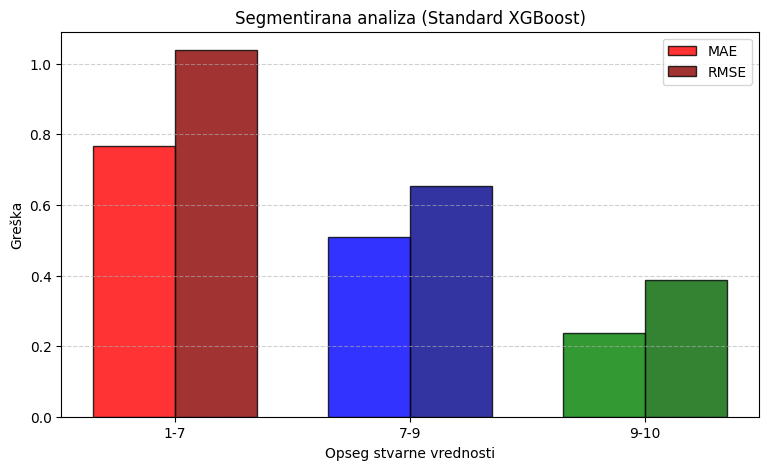

In [6]:
# Standardni XGBoost
models.plot_segmented_analysis(results_standard, title="Segmentirana analiza (Standard XGBoost)")

Na grafikonu iznad možemo uočiti znatan porast grešaka, pri nižim vrednostima zavisnosti.

Broj uzoraka po segmentima:
1-7: 140
7-9: 202
9-10: 588

Rezultati po segmentima:
1-7: MAE = 0.7561, RMSE = 1.0458
7-9: MAE = 0.5014, RMSE = 0.6459
9-10: MAE = 0.2806, RMSE = 0.4295


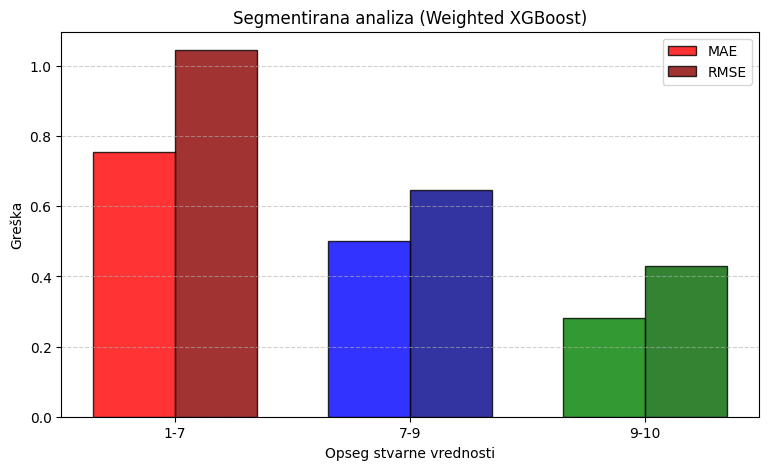

In [7]:
# Weighted XGBoost
models.plot_segmented_analysis(results_weighted, title="Segmentirana analiza (Weighted XGBoost)")

Broj uzoraka i MAE po segmentima:
1-7: n=140, Standard XGBoost MAE=0.7669, Weighted XGBoost MAE=0.7561
7-9: n=202, Standard XGBoost MAE=0.5090, Weighted XGBoost MAE=0.5014
9-10: n=588, Standard XGBoost MAE=0.2382, Weighted XGBoost MAE=0.2806


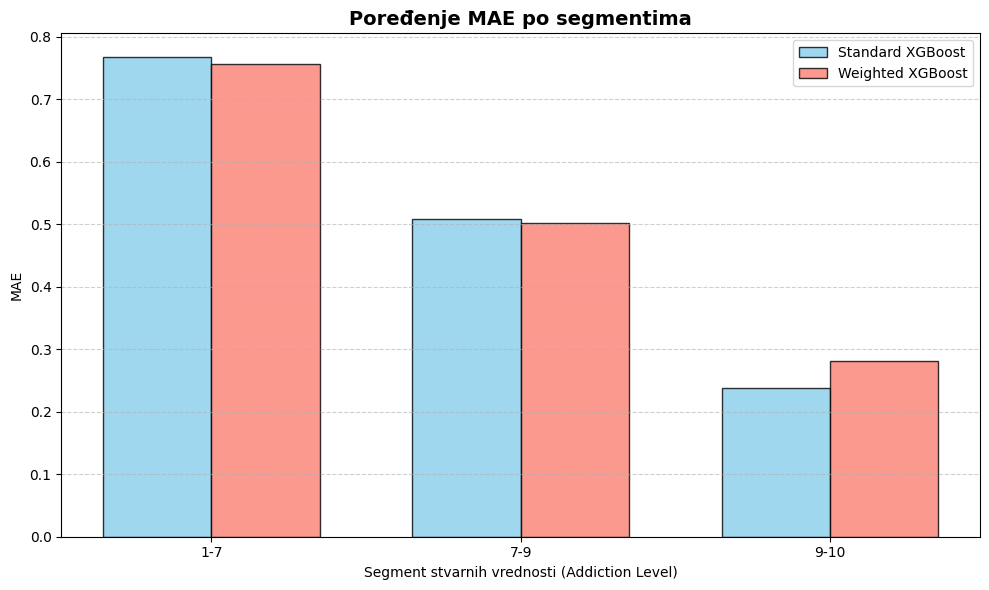

Broj uzoraka i MAE po segmentima:
1-7: n=140, Standard XGBoost MAE=0.7669, SMOTE XGBoost MAE=0.7175
7-9: n=202, Standard XGBoost MAE=0.5090, SMOTE XGBoost MAE=0.4852
9-10: n=588, Standard XGBoost MAE=0.2382, SMOTE XGBoost MAE=0.3188


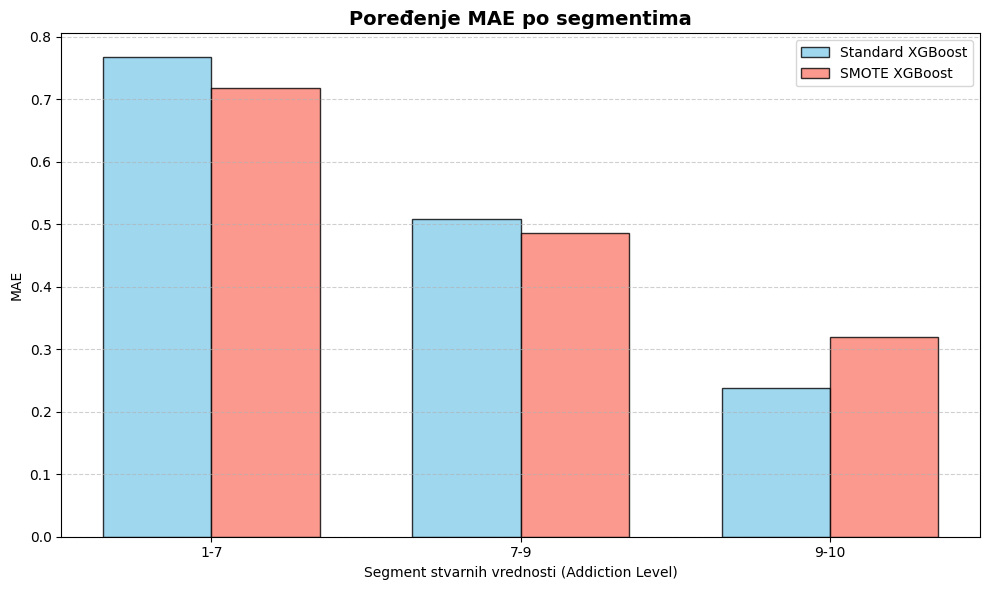

In [8]:
models.compare_segmented_mae(results_standard, results_weighted, labels=("Standard XGBoost", "Weighted XGBoost"))
models.compare_segmented_mae(results_standard,results_smote, labels=("Standard XGBoost", "SMOTE XGBoost"))

Na osnovu grafikona i priloženih rezultata, možemo konstatovati da je primena težinskog faktora bila uspešna. Glavni cilj balansiranja je da model više vrednuje ređe podatke. 

Segment 1-7 beleži mali napredak, gde je MAE pao sa 0.67 na 0.65. Uspeh je ipak ograničen malim pojavljivanjem ovih vrednosti.

Segment 7-9 beleži značajniji uspeh, gde je MAE smanjem sa 0.467 na 0.428, što pokazuje da je model postao osetljiviji na ove vrednosti.

Segment 9-10 predstavlja cenu ovog balansiranja, gde je MAE blago porastao sa 0.24 na 0.258, što je prihvatljivo.

Konačno možemo zaključiti da se Log-smoothed inverse frequency dobro pokazao, jer minimalno pogoršava generalni rezultat, ali povećava pouzdanost predikcija u nižem i srednjem segmentu.

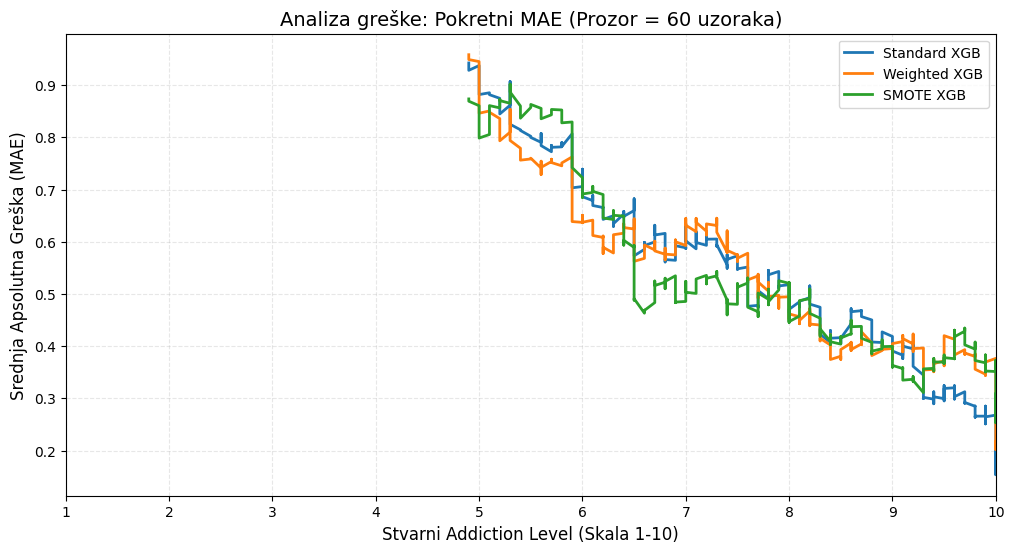

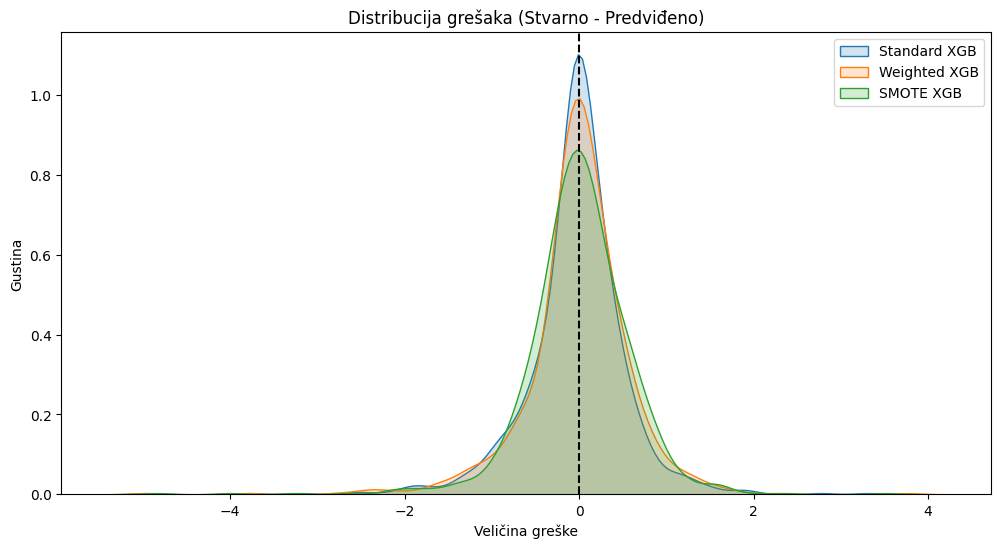

In [9]:
results_dict = {
    "Standard XGB": results_standard,
    "Weighted XGB": results_weighted,
    "SMOTE XGB": results_smote
}

models.plot_compare_rolling_mae(results_dict, window=60)

models.plot_error_distribution(results_dict=results_dict)

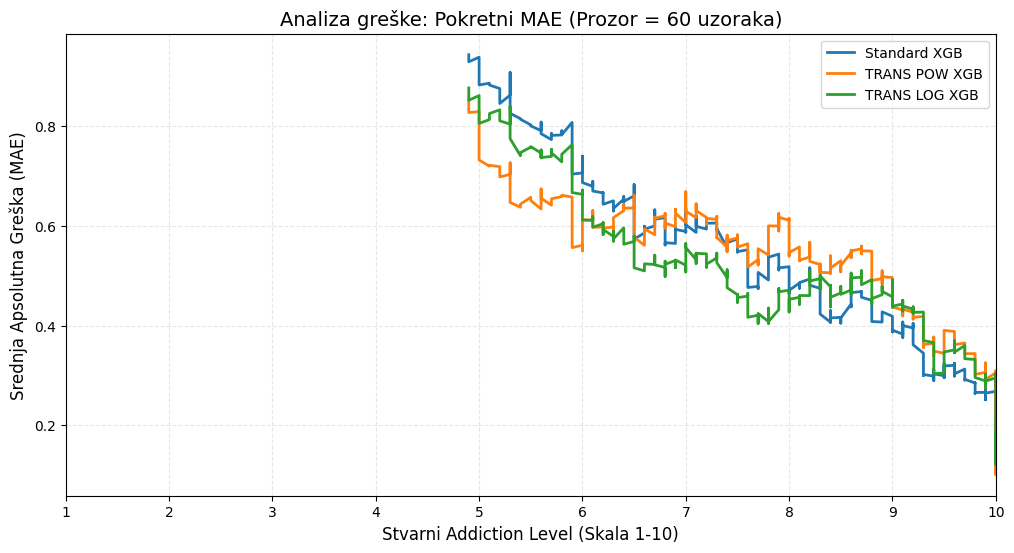

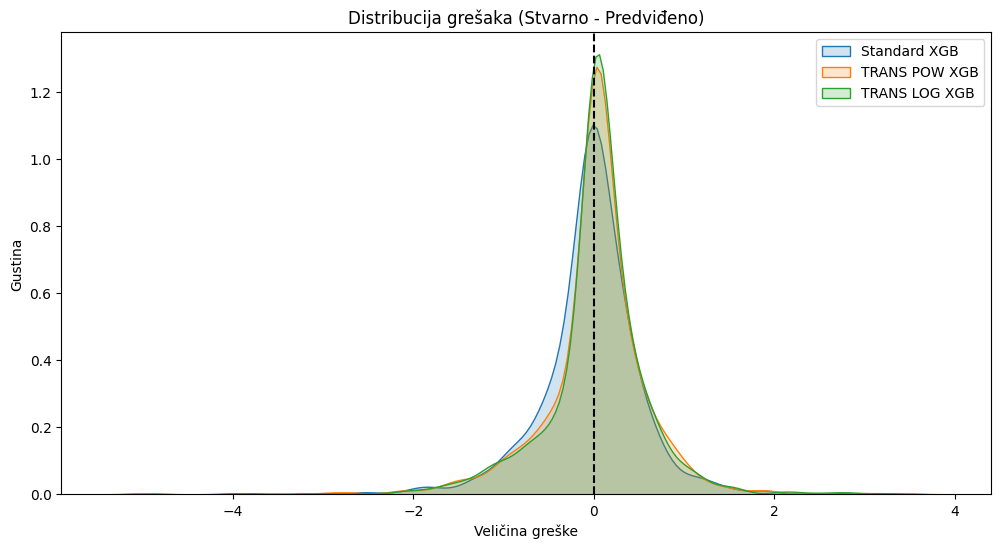

In [10]:
results_dict = {
    "Standard XGB": results_standard,
    "TRANS POW XGB": results_pow,
    "TRANS LOG XGB": results_log
}

models.plot_compare_rolling_mae(results_dict, window=60)

models.plot_error_distribution(results_dict=results_dict)